In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, data, img_as_float
from scipy.ndimage import minimum_filter, maximum_filter, uniform_filter, median_filter

In [2]:
def plot_histogram(ax, data, title, bins=50, color='blue'):
    ax.hist(data.flatten(), bins=bins, color=color, alpha=0.7, density=True)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.5)

print("Generating pure noise distributions...")
shape = (256, 256) # Size of our noise samples
U = np.random.rand(*shape) 

Generating pure noise distributions...


In [6]:
a_uni, b_uni = 0.2, 0.8
noise_uniform = a_uni + (b_uni - a_uni) * U


a_gauss, b_gauss = 0.5, 0.1
noise_gaussian = a_gauss + b_gauss * np.random.randn(*shape)
a_sp, b_sp = 0.1, 0.9
noise_sp = np.zeros_like(U)
noise_sp[(U > a_sp) & (U <= b_sp)] = 0.5
noise_sp[U > b_sp] = 1.0
a_exp = 5.0
noise_exponential = -(1.0 / a_exp) * np.log(1.0 - U + 1e-10)

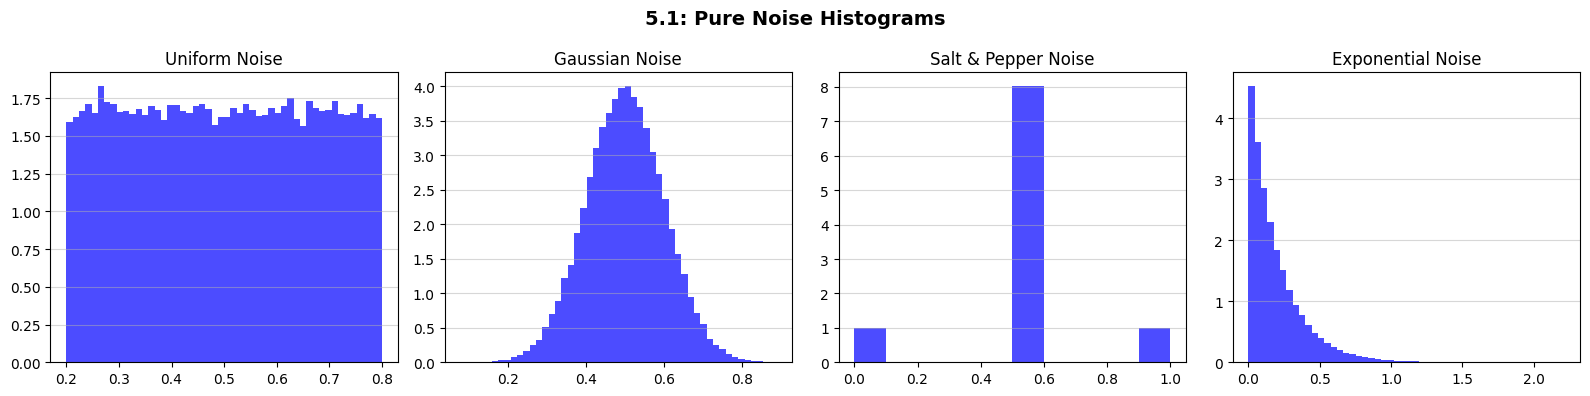

In [7]:
fig1, axes1 = plt.subplots(1, 4, figsize=(16, 4))
plot_histogram(axes1[0], noise_uniform, 'Uniform Noise')
plot_histogram(axes1[1], noise_gaussian, 'Gaussian Noise')
plot_histogram(axes1[2], noise_sp, 'Salt & Pepper Noise', bins=10)
plot_histogram(axes1[3], noise_exponential, 'Exponential Noise')
fig1.suptitle("5.1: Pure Noise Histograms", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
image = img_as_float(data.camera())